# Assumptions
- `ConvertedCompYearly` represents annual compensation already converted into USD and is the prediction target.
- The intended modelling population is employed respondents with a positive reported salary.
- Annual salaries of exactly USD 1 are treated as implausible survey responses and removed.
- Values above 70 years for `YearsCode` or `WorkExp` are treated as implausible, while high positive salaries are retained because they may be genuine.
- The first semicolon-separated value in `DevType` is treated as the respondent's primary developer role.
- Missing numerical values are replaced using training-data medians, while missing categorical values are labelled `Unknown`.
- MAE in USD is the primary final evaluation metric; RMSE, MSE, median absolute error and R² provide supporting evidence.


# Developer Salary Prediction: Final Model Development

## Business problem

This project estimates a professional developer's annual salary in USD using
structured responses from the Stack Overflow Developer Survey. The intended
user is a developer who wants a rough market estimate based on their country,
experience, role, education and work situation.


## Import libraries

In [2]:
## Import every library used in the notebook from one place
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

from matplotlib.ticker import StrMethodFormatter
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# 1. Business Understanding

Goal: Estimate an employed developer's annual salary in USD using their country, experience, role, education and work situation.

The prediction is intended as a rough market estimate rather than a guaranteed salary offer. It can help a developer form more realistic salary expectations, but survey bias, country-level market differences and unusual compensation records limit the precision of any individual prediction.

**Student input required:** Add 2–3 sentences in your own words explaining who faces this problem, what decision the prediction supports, and what could happen if the estimate is inaccurate.

# 2. Data Understanding

## 2.1 Load dataset

In [3]:
## Load the same survey file and store the target column name once
FILE_PATH = "results.csv"
col_y = "ConvertedCompYearly"

df = pd.read_csv(FILE_PATH, low_memory=False)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (49191, 172)


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


## 2.2 Summary Statistics

In [4]:
## Inspect variable types and non-missing counts before selecting features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB


In [5]:
## Measure missingness because highly incomplete columns may be unreliable model inputs
missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
}).sort_values("Missing Percentage", ascending=False)

missing_summary.head(20)

,Missing Values,Missing Percentage
AIAgentObsWrite,48927,99.46
SOTagsWant Entry,48761,99.13
SOTagsHaveEntry,48733,99.07
AIModelsWantEntry,48716,99.03
AIAgentOrchWrite,48713,99.03
JobSatPoints_15_TEXT,48527,98.65
AIAgentKnowWrite,48425,98.44
AIModelsHaveEntry,48415,98.42
SO_Actions_15_TEXT,48368,98.33
AIAgentExtWrite,48332,98.25


In [6]:
## Describe numerical and categorical variables to identify ranges and unusual values
df[col_y] = pd.to_numeric(df[col_y], errors="coerce")
summary_statistics = df.describe(include="all").T

summary_statistics

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ResponseId,49191.0,NaN,NaN,NaN,24596.0,14200.362883,1.0,12298.5,24596.0,36893.5,49191.0
MainBranch,49191,6,I am a developer by profession,37467,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,49191,7,25-34 years old,16519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EdLevel,48149,8,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",20278,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Employment,48339,6,Employed,33750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
AIAgentExtWrite,859,421,Cursor,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AIHuman,29194,574,When I don’t trust AI’s answers;When I want to...,3050,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AIOpen,22540,20138,Problem solving,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ConvertedCompYearly,23947.0,NaN,NaN,NaN,101761.539901,461756.901211,1.0,38171.0,75320.0,120596.0,50000000.0


In [7]:
## Examine detailed salary percentiles because the target contains extreme values
df[col_y].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
90%      1.840000e+05
95%      2.320290e+05
99%      4.408560e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

The target has many missing responses and is strongly right-skewed: the maximum is far above the 99th percentile. This means a small number of extreme salaries could dominate squared-error measures, so both the raw USD target and a log-transformed training target are considered later.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

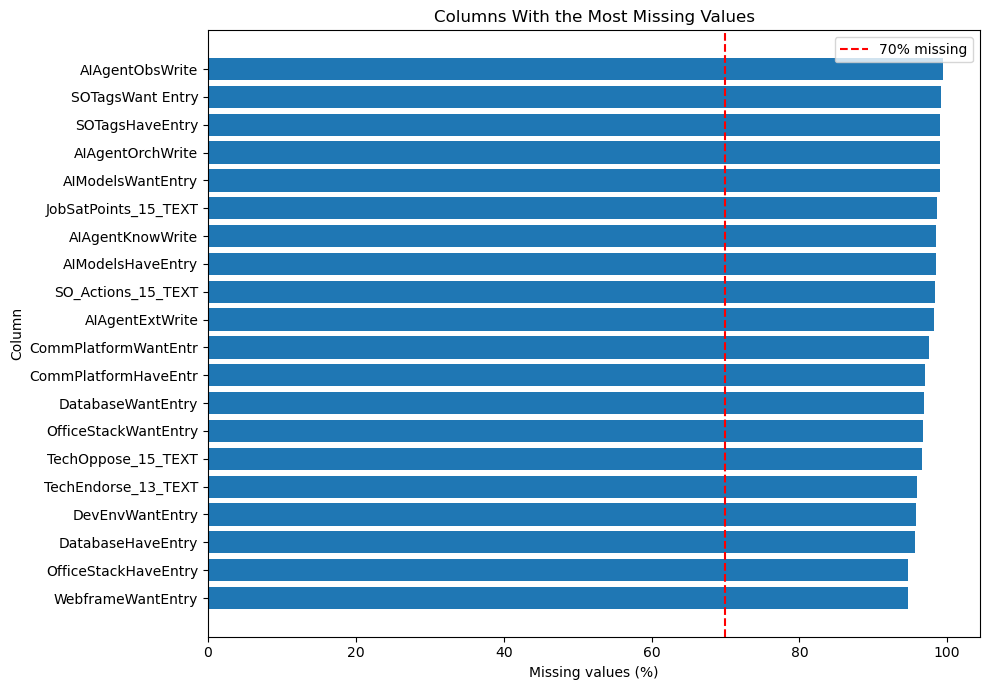

In [8]:
## Visualise missingness to support the decision to use a focused feature set
top_missing = missing_summary.head(20).sort_values("Missing Percentage")

plt.figure(figsize=(10, 7))
plt.barh(top_missing.index, top_missing["Missing Percentage"])
plt.axvline(x=70, color="red", linestyle="--", label="70% missing")
plt.title("Columns With the Most Missing Values")
plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.legend()
plt.tight_layout()
plt.show()

Several survey questions contain very high levels of missing data, so including every column would create a large and unreliable input space. Salary 4.0 therefore keeps a smaller set of features that are relevant to the business problem and handles missing values only after the train-test split.

### 2.3.1.1 Understanding distribution of target

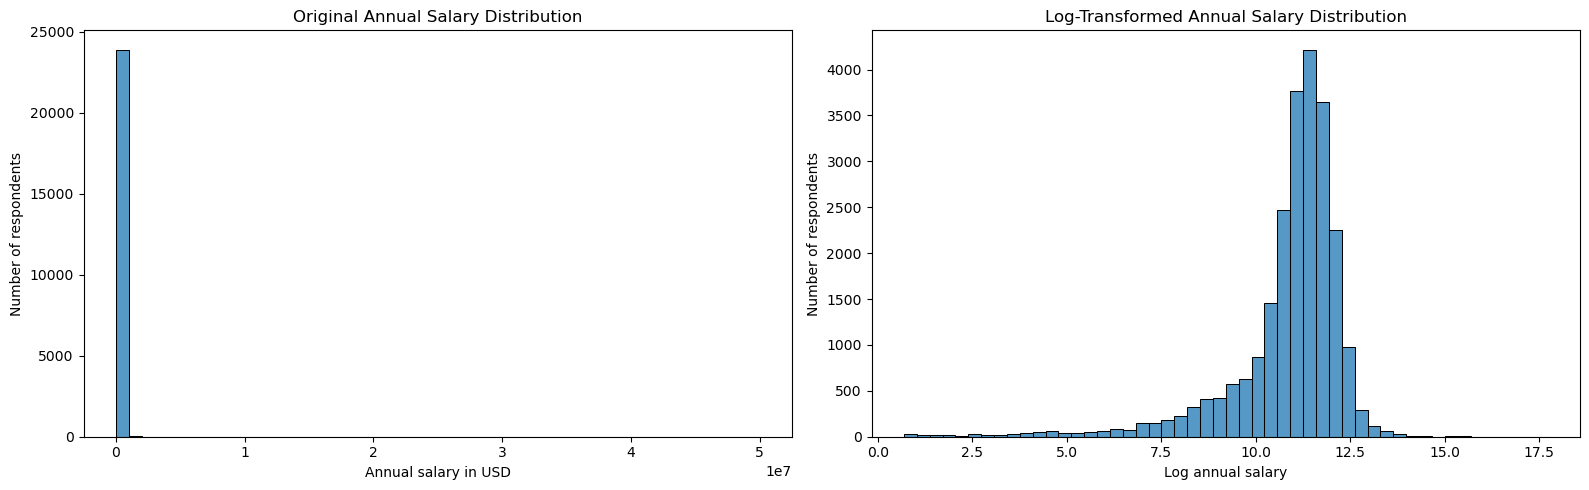

In [9]:
## Compare the original target with its log transformation to see the effect of extreme salaries
salary_values = df[col_y].dropna()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(salary_values, bins=50, ax=axes[0])
axes[0].set_title("Original Annual Salary Distribution")
axes[0].set_xlabel("Annual salary in USD")
axes[0].set_ylabel("Number of respondents")

sns.histplot(np.log1p(salary_values), bins=50, ax=axes[1])
axes[1].set_title("Log-Transformed Annual Salary Distribution")
axes[1].set_xlabel("Log annual salary")
axes[1].set_ylabel("Number of respondents")

plt.tight_layout()
plt.show()

The original target is strongly right-skewed because a small number of respondents reported extremely high salaries. The log transformation compresses those values and creates a more balanced training target, while final predictions are converted back into normal USD for evaluation.

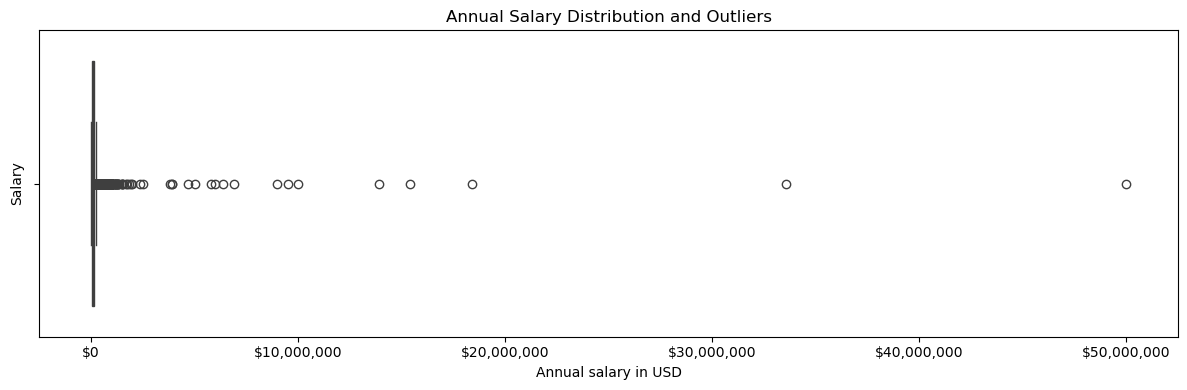

In [10]:
## Use a box plot to make the target's extreme upper values visible
plt.figure(figsize=(12, 4))
sns.boxplot(x=df[col_y].dropna())
plt.title("Annual Salary Distribution and Outliers")
plt.xlabel("Annual salary in USD")
plt.ylabel("Salary")
plt.gca().xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.show()

The box plot confirms that reported salaries contain many upper outliers. These values are retained because they may be genuine, but the log target and robust `huber` loss reduce their influence during Gradient Boosting training.

### 2.3.1.2 Understanding distribution of features

In [11]:
## Prepare an EDA copy so exploration does not alter the main DataFrame
eda_df = df[df[col_y].notna() & (df[col_y] > 0)].copy()
eda_df["WorkExp"] = pd.to_numeric(eda_df["WorkExp"], errors="coerce")
eda_df["PrimaryDevType"] = eda_df["DevType"].fillna("Unknown").astype(str).str.split(";").str[0].str.strip()

print("Rows available for EDA:", len(eda_df))

Rows available for EDA: 23947


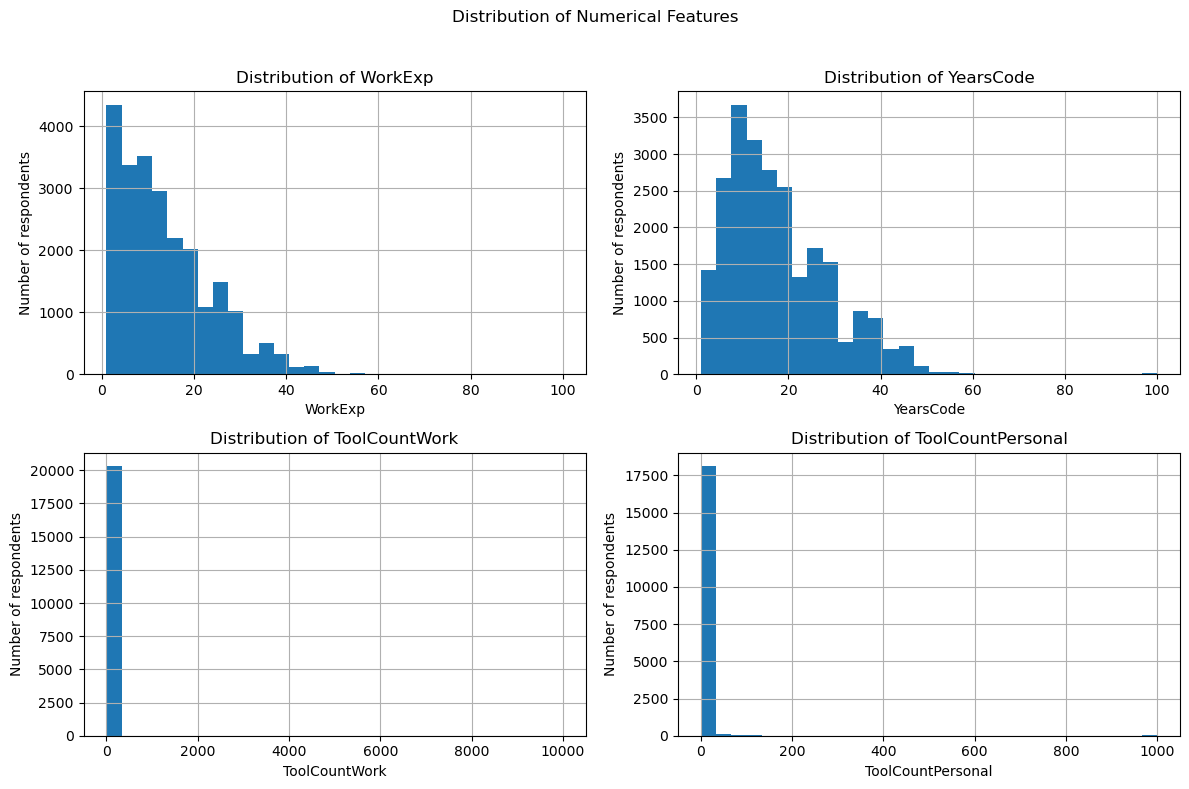

In [12]:
## Plot numerical feature distributions to identify skewness and implausible ranges
eda_numerical_features = ["WorkExp", "YearsCode", "ToolCountWork", "ToolCountPersonal"]
feature_distribution_df = eda_df[eda_numerical_features].copy()

for column in eda_numerical_features:
    feature_distribution_df[column] = feature_distribution_df[column].replace({"Less than 1 year": 0.5, "More than 50 years": 51})
    feature_distribution_df[column] = pd.to_numeric(feature_distribution_df[column], errors="coerce")

axes = feature_distribution_df.hist(figsize=(12, 8), bins=30)
for axis in axes.flatten():
    feature_name = axis.get_title()
    axis.set_title(f"Distribution of {feature_name}")
    axis.set_xlabel(feature_name)
    axis.set_ylabel("Number of respondents")

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Experience values are concentrated in the lower and middle ranges, while a small number of unusually large values appear. This supports converting the fields to numeric values, removing impossible values above 70 years and using median imputation for missing numerical data.

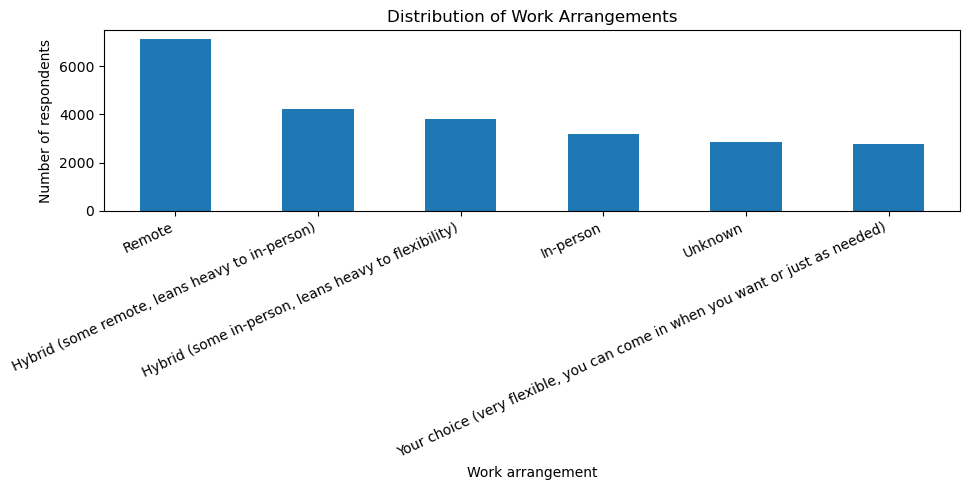

In [13]:
## Show the distribution of work arrangements because it is a selected categorical feature
remote_counts = eda_df["RemoteWork"].fillna("Unknown").value_counts()
remote_counts.plot(kind="bar", figsize=(10, 5))
plt.title("Distribution of Work Arrangements")
plt.xlabel("Work arrangement")
plt.ylabel("Number of respondents")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

The work-arrangement categories are not equally represented, so the model may learn more reliably about common arrangements than rare ones. Missing work-arrangement responses are retained as an `Unknown` category instead of deleting otherwise useful rows.

### 2.3.2 Understanding relationship between variables

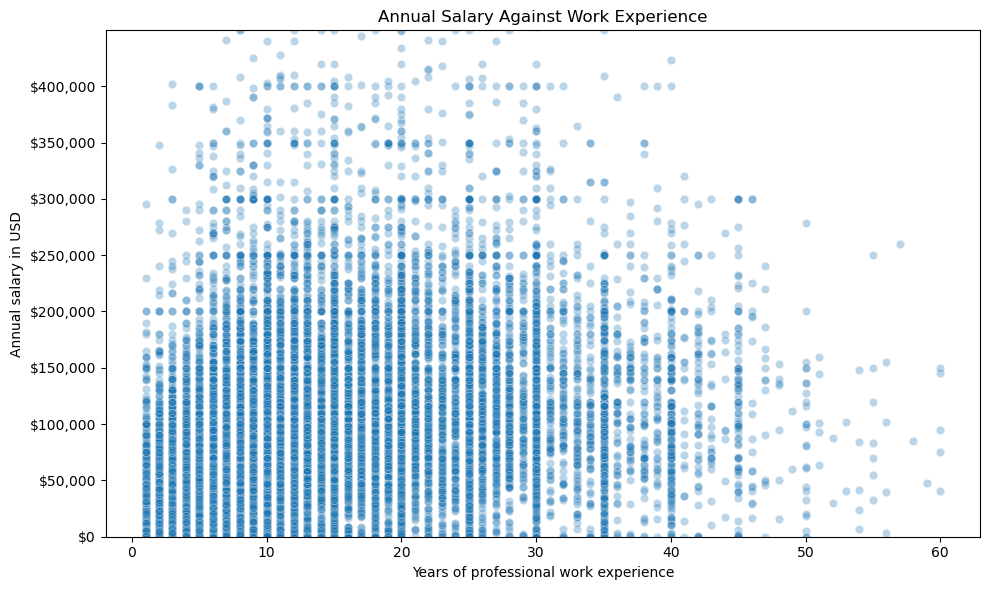

In [14]:
## Compare work experience with salary while limiting only the displayed salary range
work_experience_df = eda_df[eda_df["WorkExp"].between(0, 60)].copy()
salary_display_limit = work_experience_df[col_y].quantile(0.99)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=work_experience_df, x="WorkExp", y=col_y, alpha=0.3)
plt.ylim(0, salary_display_limit)
plt.title("Annual Salary Against Work Experience")
plt.xlabel("Years of professional work experience")
plt.ylabel("Annual salary in USD")
plt.gca().yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.show()

Salaries vary greatly among respondents with the same amount of experience, so experience alone cannot explain salary accurately. Other selected factors such as role, country, education and organisation size are needed to capture additional differences.

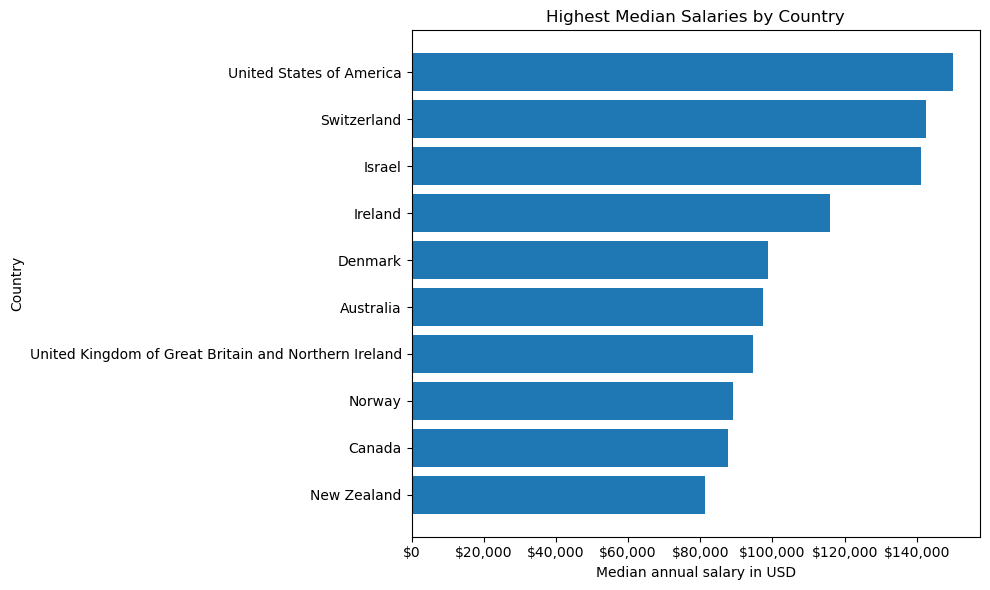

In [15]:
## Compare common countries so very small groups do not create misleading median salaries
country_counts = eda_df["Country"].value_counts()
common_countries = country_counts[country_counts >= 100].index
country_salary = eda_df[eda_df["Country"].isin(common_countries)].groupby("Country")[col_y].median().sort_values(ascending=False).head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(country_salary.index, country_salary.values)
plt.title("Highest Median Salaries by Country")
plt.xlabel("Median annual salary in USD")
plt.ylabel("Country")
plt.gca().xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.show()

The large differences between country medians suggest that location contains useful salary information. However, this relationship should not be treated as causal because living costs, seniority and the mix of roles also differ between countries.

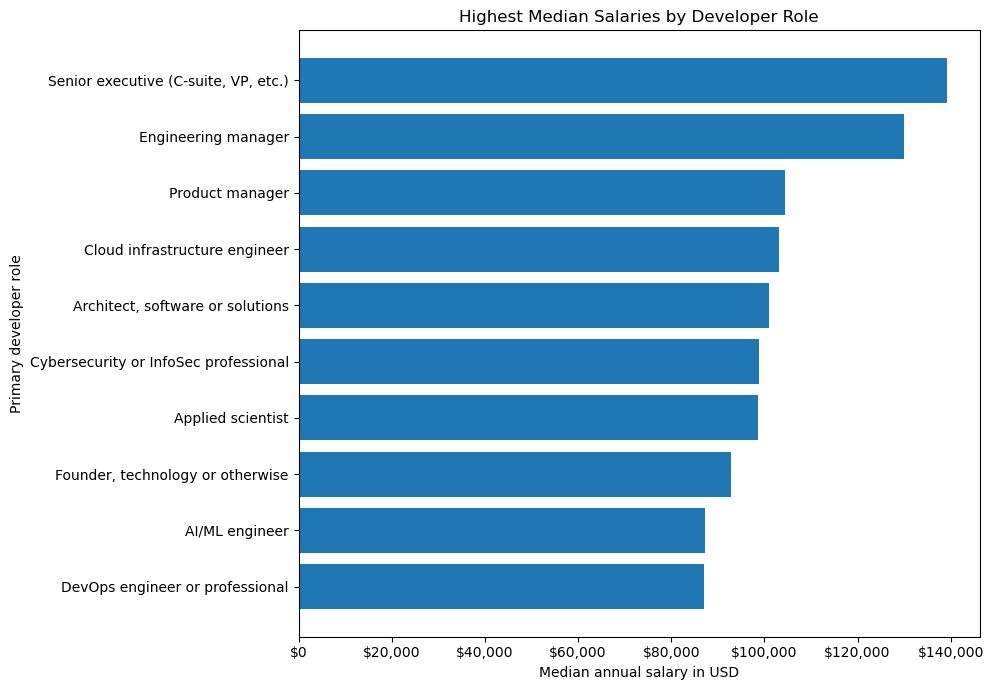

In [16]:
## Compare common developer roles because responsibilities and seniority may affect salary
role_counts = eda_df["PrimaryDevType"].value_counts()
common_roles = role_counts[role_counts >= 50].index
role_salary = eda_df[eda_df["PrimaryDevType"].isin(common_roles)].groupby("PrimaryDevType")[col_y].median().sort_values(ascending=False).head(10).sort_values()

plt.figure(figsize=(10, 7))
plt.barh(role_salary.index, role_salary.values)
plt.title("Highest Median Salaries by Developer Role")
plt.xlabel("Median annual salary in USD")
plt.ylabel("Primary developer role")
plt.gca().xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.show()

Leadership and specialised roles have higher median salaries than many general developer roles. Keeping a simplified `PrimaryDevType` feature therefore preserves useful role information without creating a very sparse multi-role representation.

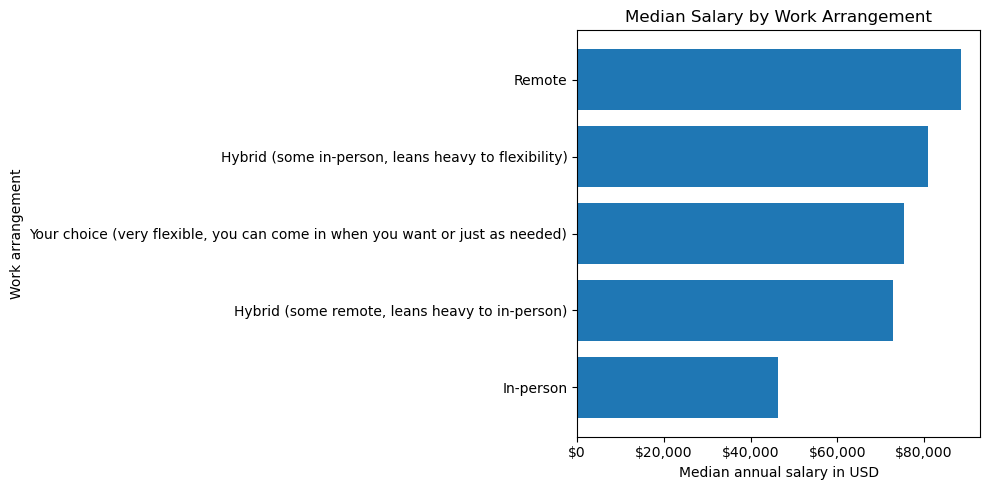

In [17]:
## Compare salary by work arrangement without claiming that the relationship is causal
remote_salary = eda_df.groupby("RemoteWork")[col_y].median().sort_values()

plt.figure(figsize=(10, 5))
plt.barh(remote_salary.index, remote_salary.values)
plt.title("Median Salary by Work Arrangement")
plt.xlabel("Median annual salary in USD")
plt.ylabel("Work arrangement")
plt.gca().xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.show()

Remote and flexible arrangements have different median salaries from in-person arrangements. This supports retaining `RemoteWork`, although country, role and experience may partly explain the relationship.

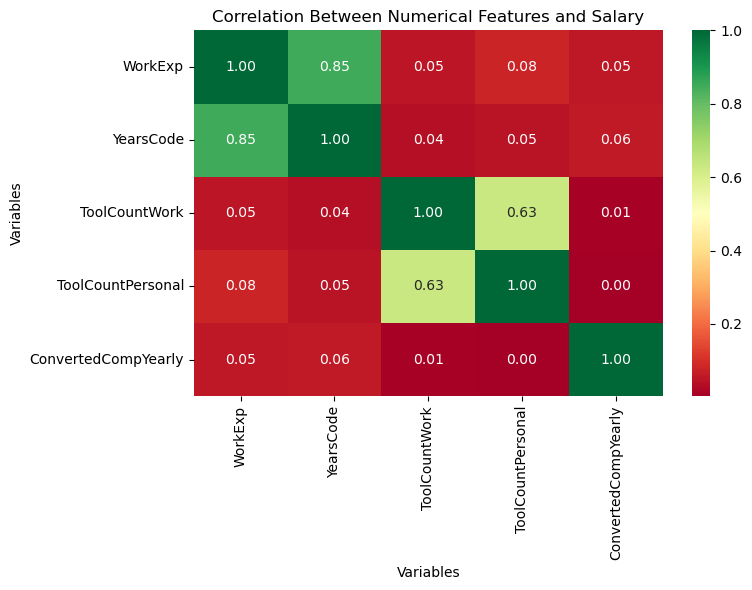

In [18]:
## Check linear relationships among numerical variables before modelling
correlation_df = feature_distribution_df.copy()
correlation_df[col_y] = eda_df.loc[feature_distribution_df.index, col_y]

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_df.corr(), annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Correlation Between Numerical Features and Salary")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

The numerical features do not have a single strong linear relationship with salary. This supports comparing tree-based models, which can capture nonlinear patterns and interactions that a simple straight-line relationship may miss.

# 3. Data Preparation

## 3.1 Data Cleaning

In [19]:
## Investigate USD 1 salaries before removing them so the cleaning decision remains visible
review_columns = [column for column in ["ResponseId", "Employment", "Country", "WorkExp", "YearsCode", "CompTotal", "Currency", col_y] if column in df.columns]
salary_one_rows = df[df[col_y] == 1][review_columns]

print("Number of rows with a salary of exactly USD 1:", len(salary_one_rows))
salary_one_rows.head(20)

Number of rows with a salary of exactly USD 1: 28


,ResponseId,Employment,Country,WorkExp,YearsCode,CompTotal,Currency,ConvertedCompYearly
90,91,Employed,India,4.0,6.0,50.0,INR Indian rupee,1.0
1764,1765,Employed,Viet Nam,10.0,17.0,26000.0,VND\tVietnamese dong,1.0
4580,4581,Student,Germany,6.0,6.0,1.0,EUR European Euro,1.0
5910,5911,Employed,India,13.0,13.0,45.0,INR Indian rupee,1.0
8405,8406,Retired,"Micronesia, Federated States of...",40.0,40.0,1.0,EUR European Euro,1.0
9012,9013,Employed,Turkey,12.0,6.0,27.0,TRY\tTurkish lira,1.0
12407,12408,Employed,Indonesia,5.0,7.0,15000.0,IDR\tIndonesian rupiah,1.0
12559,12560,"Independent contractor, freelancer, or self-em...",Ukraine,42.0,39.0,1.0,USD United States dollar,1.0
12980,12981,Student,Nepal,NaN,1.0,100.0,NPR\tNepalese rupee,1.0
13304,13305,Employed,India,7.0,10.0,56.0,INR Indian rupee,1.0


Exactly USD 1 is not a realistic annual developer salary and appears across different currencies and employment situations. These records are treated as reporting or conversion errors, so employed USD 1 rows are removed before modelling instead of allowing them to distort the target.

In [20]:
## Keep the paid-employed population because it matches the intended application user
model_df = df.copy()
model_df = model_df[model_df["Employment"].eq("Employed") & model_df[col_y].notna() & (model_df[col_y] > 0)].copy()

salary_one_count = (model_df[col_y] == 1).sum()
model_df = model_df[model_df[col_y] != 1].copy()

print("Employed USD 1 salary rows removed:", salary_one_count)

Employed USD 1 salary rows removed: 13


In [21]:
## Convert numeric-like fields and remove impossible experience values before splitting
numeric_like_columns = ["YearsCode", "WorkExp", "ToolCountWork", "ToolCountPersonal"]

for column in numeric_like_columns:
    model_df[column] = model_df[column].replace({"Less than 1 year": 0.5, "More than 50 years": 51})
    model_df[column] = pd.to_numeric(model_df[column], errors="coerce")

invalid_experience_rows = (model_df["YearsCode"] > 70) | (model_df["WorkExp"] > 70)
print("Impossible experience rows removed:", invalid_experience_rows.sum())

model_df = model_df[~invalid_experience_rows].copy()

print("Rows remaining for modelling:", len(model_df))
print("Salaries above USD 1 million retained:", (model_df[col_y] > 1_000_000).sum())

Impossible experience rows removed: 8
Rows remaining for modelling: 19479
Salaries above USD 1 million retained: 31


The experience limit removes values that are not credible for a respondent's working lifetime. High positive salaries are not automatically deleted because they may represent genuine senior or specialised compensation; their influence is handled through the log target rather than an arbitrary salary cap.

In [22]:
## Keep the first listed role and select the same 14 Salary 4.0 features
model_df["PrimaryDevType"] = model_df["DevType"].fillna("Unknown").astype(str).str.split(";").str[0].str.strip()

numerical_features = ["WorkExp", "YearsCode", "ToolCountWork", "ToolCountPersonal"]
categorical_features = ["Country", "Age", "EdLevel", "PrimaryDevType", "OrgSize", "ICorPM", "RemoteWork", "Industry", "PurchaseInfluence", "NewRole"]
selected_features = numerical_features + categorical_features

x = model_df[selected_features].copy()
y = model_df[col_y].copy()

print("Selected features:", selected_features)
print("Number of selected features:", len(selected_features))

Selected features: ['WorkExp', 'YearsCode', 'ToolCountWork', 'ToolCountPersonal', 'Country', 'Age', 'EdLevel', 'PrimaryDevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'Industry', 'PurchaseInfluence', 'NewRole']
Number of selected features: 14


`PrimaryDevType` keeps role information while avoiding a large multi-label feature space; its limitation is that secondary roles are discarded. The 14 selected features represent experience, role, education, location and work context. Identifier fields, free-text responses and very sparse opinion questions are excluded because they are not stable user inputs, while `CompTotal`, `Currency` and the target itself are excluded from `x` to avoid compensation leakage or duplication.

## 3.2 Train-Test Split

In [23]:
## Fix the split settings once so every model receives the same training and test rows
test_size = 0.20
random_state = 676767

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=random_state)

print("Training size:", x_train.shape)
print("Testing size:", x_test.shape)

Training size: (15583, 14)
Testing size: (3896, 14)


The same split is reused for every baseline, algorithm, PCA experiment and tuned model so their test metrics are directly comparable within Salary 4.0. Preprocessing values are learned from `x_train` only to reduce data leakage.

In [24]:
## Use training medians so test-set information cannot influence numerical imputation
training_medians = x_train[numerical_features].median()
x_train_numeric = x_train[numerical_features].fillna(training_medians)
x_test_numeric = x_test[numerical_features].fillna(training_medians)

print("Training medians:")
print(training_medians)

Training medians:
WorkExp              11.0
YearsCode            15.0
ToolCountWork         7.0
ToolCountPersonal     4.0
dtype: float64


In [25]:
## Preserve rows with missing categories because Unknown can carry useful information
x_train_categorical = x_train[categorical_features].fillna("Unknown").astype(str)
x_test_categorical = x_test[categorical_features].fillna("Unknown").astype(str)

In [26]:
## Group rare training categories once to reduce sparse encoded columns
category_limits = {"Country": 20, "Industry": 15, "PrimaryDevType": 15}
top_categories = {}

for column, limit in category_limits.items():
    top_categories[column] = x_train_categorical[column].value_counts().head(limit).index.tolist()
    x_train_categorical[column] = x_train_categorical[column].where(x_train_categorical[column].isin(top_categories[column]), "Other")
    x_test_categorical[column] = x_test_categorical[column].where(x_test_categorical[column].isin(top_categories[column]), "Other")

Rare countries, industries and roles are grouped using training frequencies only. This reduces high-cardinality noise and the number of near-empty dummy columns, but it also loses detail for uncommon categories; the PCA and model comparisons show whether the resulting representation remains useful.

In [27]:
## One-hot encode categories and align test columns with the training structure
training_category_levels = {column: sorted(x_train_categorical[column].unique().tolist()) for column in categorical_features}

for column in categorical_features:
    x_train_categorical[column] = pd.Categorical(x_train_categorical[column], categories=training_category_levels[column])
    x_test_categorical[column] = pd.Categorical(x_test_categorical[column], categories=training_category_levels[column])

x_train_categorical = pd.get_dummies(x_train_categorical, drop_first=True, dtype=int)
x_test_categorical = pd.get_dummies(x_test_categorical, drop_first=True, dtype=int)
x_test_categorical = x_test_categorical.reindex(columns=x_train_categorical.columns, fill_value=0)

print("Encoded categorical features:", x_train_categorical.shape[1])

Encoded categorical features: 90


In [28]:
## Combine numerical and encoded categorical inputs into the final model matrices
x_train_encoded = pd.concat([x_train_numeric, x_train_categorical], axis=1).astype(float)
x_test_encoded = pd.concat([x_test_numeric, x_test_categorical], axis=1).astype(float)
x_test_encoded = x_test_encoded.reindex(columns=x_train_encoded.columns, fill_value=0)

print("Final training shape:", x_train_encoded.shape)
print("Final testing shape:", x_test_encoded.shape)

Final training shape: (15583, 94)
Final testing shape: (3896, 94)


In [29]:
## Standardise only the PCA copy because PCA is sensitive to feature scale
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_encoded)
x_test_scaled = scaler.transform(x_test_encoded)

pca = PCA(n_components=0.95, svd_solver="full")
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print("Features before PCA:", x_train_encoded.shape[1])
print("Components after PCA:", x_train_pca.shape[1])
print("Variance retained:", round(pca.explained_variance_ratio_.sum(), 4))

Features before PCA: 94
Components after PCA: 79
Variance retained: 0.9573


PCA is tested rather than assumed to improve performance. Standardisation prevents large-scale numerical features from dominating the components, and retaining 95% variance gives a smaller representation that can be compared fairly with the original encoded features.

# 4. Modelling

### 4.2 Train Model

In [30]:
## Evaluate every model immediately in normal USD using the same metric set
model_results = []

def evaluate_model(model_name, actual_values, predicted_values):
    predicted_values = np.maximum(predicted_values, 0)
    result = {
        "Model": model_name,
        "MAE": mean_absolute_error(actual_values, predicted_values),
        "Median Absolute Error": median_absolute_error(actual_values, predicted_values),
        "MSE": mean_squared_error(actual_values, predicted_values),
        "RMSE": root_mean_squared_error(actual_values, predicted_values),
        "R2": r2_score(actual_values, predicted_values)
    }
    model_results.append(result)
    print(model_name)
    print(f"MAE: {result['MAE']}")
    print(f"Median Absolute Error: {result['Median Absolute Error']}")
    print(f"MSE: {result['MSE']}")
    print(f"RMSE: {result['RMSE']}")
    print(f"R²: {result['R2']}")
    return result

In [31]:
## Log-transform only the training target to reduce the influence of extreme salaries
y_train_log = np.log1p(y_train)

#### Model 1: Decision Tree

In [32]:
## Train and evaluate a single tree as a simple nonlinear comparison model
dtree = DecisionTreeRegressor(random_state=random_state)
dtree.fit(x_train_encoded, y_train_log)
y_pred_dtree = np.expm1(dtree.predict(x_test_encoded))

dtree_result = evaluate_model("Decision Tree", y_test, y_pred_dtree)

Decision Tree
MAE: 66314.83290554413
Median Absolute Error: 29099.999999999993
MSE: 312046507513.6715
RMSE: 558611.2311023397
R²: -15.806288467106071


#### Model 2: Random Forest

In [33]:
## Train and evaluate many independent trees to reduce single-tree variance
rtree = RandomForestRegressor(random_state=random_state, n_jobs=-1)
rtree.fit(x_train_encoded, y_train_log)
y_pred_rtree = np.expm1(rtree.predict(x_test_encoded))

rtree_result = evaluate_model("Random Forest", y_test, y_pred_rtree)

Random Forest
MAE: 38351.502555222265
Median Absolute Error: 20476.615826078058
MSE: 15781667495.006414
RMSE: 125625.10694525365
R²: 0.15002651839835557


#### Model 3: Gradient Boosting

In [34]:
## Train and evaluate sequential trees that correct earlier prediction errors
gtree = GradientBoostingRegressor(loss="huber", random_state=random_state)
gtree.fit(x_train_encoded, y_train_log)
y_pred_gtree = np.expm1(gtree.predict(x_test_encoded))

gtree_result = evaluate_model("Gradient Boosting", y_test, y_pred_gtree)

Gradient Boosting
MAE: 36593.87811259719
Median Absolute Error: 19640.30083820815
MSE: 15518270840.05944
RMSE: 124572.35182840309
R²: 0.1642126094383769


#### Model 4: Decision Tree with PCA

In [35]:
## Test the same Decision Tree algorithm on the PCA representation
dtree_pca = DecisionTreeRegressor(random_state=random_state)
dtree_pca.fit(x_train_pca, y_train_log)
y_pred_dtree_pca = np.expm1(dtree_pca.predict(x_test_pca))

dtree_pca_result = evaluate_model("Decision Tree + PCA", y_test, y_pred_dtree_pca)

Decision Tree + PCA
MAE: 67351.53311088296
Median Absolute Error: 35455.499999999985
MSE: 74662020410.03105
RMSE: 273243.5185142203
R²: -3.021168070573479


#### Model 5: Random Forest with PCA

In [36]:
## Test the same Random Forest algorithm on the PCA representation
rtree_pca = RandomForestRegressor(random_state=random_state, n_jobs=-1)
rtree_pca.fit(x_train_pca, y_train_log)
y_pred_rtree_pca = np.expm1(rtree_pca.predict(x_test_pca))

rtree_pca_result = evaluate_model("Random Forest + PCA", y_test, y_pred_rtree_pca)

Random Forest + PCA
MAE: 41293.7290255137
Median Absolute Error: 22625.76819395594
MSE: 16282972195.089422
RMSE: 127604.74989235088
R²: 0.12302710902620617


#### Model 6: Gradient Boosting with PCA

In [37]:
## Test the same Gradient Boosting algorithm on the PCA representation
gtree_pca = GradientBoostingRegressor(loss="huber", random_state=random_state)
gtree_pca.fit(x_train_pca, y_train_log)
y_pred_gtree_pca = np.expm1(gtree_pca.predict(x_test_pca))

gtree_pca_result = evaluate_model("Gradient Boosting + PCA", y_test, y_pred_gtree_pca)

Gradient Boosting + PCA
MAE: 39400.773845751464
Median Absolute Error: 21442.892856420673
MSE: 15974094554.937082
RMSE: 126388.66466157905
R²: 0.13966272774471322


The original Salary 4.0 results showed that PCA increased MAE for all three algorithms. The non-PCA Random Forest and Gradient Boosting versions are therefore tuned, while Decision Tree is not tuned because its untuned MAE was worse than the median baseline.

#### Model 7: Tuned Random Forest

In [38]:
## Tune four Random Forest hyperparameters using no more than three values each
rtree_parameters = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rtree_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=random_state, n_jobs=-1),
    param_distributions=rtree_parameters,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=random_state,
    n_jobs=-1
)

rtree_search.fit(x_train_encoded, y_train_log)

rtree_tuning_results = pd.DataFrame(rtree_search.cv_results_)[["params", "mean_test_score", "std_test_score", "rank_test_score"]].copy()
rtree_tuning_results["Mean CV MAE (log scale)"] = -rtree_tuning_results["mean_test_score"]
rtree_tuning_results = rtree_tuning_results.sort_values("rank_test_score")

print("Best Random Forest parameters:", rtree_search.best_params_)
print("Best CV MAE on log salary:", -rtree_search.best_score_)
rtree_tuning_results.head(10)

Best Random Forest parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': None}
Best CV MAE on log salary: 0.5926071852712104


,params,mean_test_score,std_test_score,rank_test_score,Mean CV MAE (log scale)
1,"{'n_estimators': 100, 'min_samples_split': 10,...",-0.592607,0.002937,1,0.592607
6,"{'n_estimators': 100, 'min_samples_split': 5, ...",-0.593677,0.002828,2,0.593677
5,"{'n_estimators': 200, 'min_samples_split': 5, ...",-0.596840,0.001789,3,0.596840
7,"{'n_estimators': 200, 'min_samples_split': 2, ...",-0.598111,0.002045,4,0.598111
3,"{'n_estimators': 300, 'min_samples_split': 10,...",-0.599902,0.003263,5,0.599902
8,"{'n_estimators': 200, 'min_samples_split': 5, ...",-0.600119,0.003190,6,0.600119
0,"{'n_estimators': 100, 'min_samples_split': 5, ...",-0.601566,0.002792,7,0.601566
9,"{'n_estimators': 200, 'min_samples_split': 5, ...",-0.603287,0.003120,8,0.603287
4,"{'n_estimators': 100, 'min_samples_split': 10,...",-0.603712,0.003798,9,0.603712
2,"{'n_estimators': 100, 'min_samples_split': 2, ...",-0.607898,0.004225,10,0.607898


In [39]:
## Evaluate the tuned Random Forest immediately in normal USD
rtree_tuned = rtree_search.best_estimator_
y_pred_rtree_tuned = np.expm1(rtree_tuned.predict(x_test_encoded))

rtree_tuned_result = evaluate_model("Tuned Random Forest", y_test, y_pred_rtree_tuned)

Tuned Random Forest
MAE: 37652.34560434913
Median Absolute Error: 20125.619959158837
MSE: 15711539543.55827
RMSE: 125345.6801950441
R²: 0.15380348930899168


#### Model 8: Tuned Gradient Boosting

In [40]:
## Tune four Gradient Boosting hyperparameters using no more than three values each
gtree_parameters = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.10],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10]
}

gtree_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(loss="huber", random_state=random_state),
    param_distributions=gtree_parameters,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=random_state,
    n_jobs=-1
)

gtree_search.fit(x_train_encoded, y_train_log)

gtree_tuning_results = pd.DataFrame(gtree_search.cv_results_)[["params", "mean_test_score", "std_test_score", "rank_test_score"]].copy()
gtree_tuning_results["Mean CV MAE (log scale)"] = -gtree_tuning_results["mean_test_score"]
gtree_tuning_results = gtree_tuning_results.sort_values("rank_test_score")

print("Best Gradient Boosting parameters:", gtree_search.best_params_)
print("Best CV MAE on log salary:", -gtree_search.best_score_)
gtree_tuning_results.head(10)

Best Gradient Boosting parameters: {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 4, 'learning_rate': 0.05}
Best CV MAE on log salary: 0.5523458588447068


,params,mean_test_score,std_test_score,rank_test_score,Mean CV MAE (log scale)
3,"{'n_estimators': 300, 'min_samples_split': 10,...",-0.552346,0.004945,1,0.552346
8,"{'n_estimators': 200, 'min_samples_split': 5, ...",-0.556420,0.004964,2,0.556420
9,"{'n_estimators': 200, 'min_samples_split': 5, ...",-0.564194,0.005000,3,0.564194
0,"{'n_estimators': 100, 'min_samples_split': 5, ...",-0.570005,0.004963,4,0.570005
7,"{'n_estimators': 200, 'min_samples_split': 2, ...",-0.576701,0.005328,5,0.576701
5,"{'n_estimators': 200, 'min_samples_split': 5, ...",-0.576701,0.005328,6,0.576701
1,"{'n_estimators': 100, 'min_samples_split': 10,...",-0.587080,0.005705,7,0.587080
6,"{'n_estimators': 100, 'min_samples_split': 5, ...",-0.587091,0.005608,8,0.587091
2,"{'n_estimators': 100, 'min_samples_split': 2, ...",-0.600403,0.005688,9,0.600403
4,"{'n_estimators': 100, 'min_samples_split': 10,...",-0.624420,0.006581,10,0.624420


In [41]:
## Evaluate the tuned Gradient Boosting model immediately in normal USD
gtree_tuned = gtree_search.best_estimator_
y_pred_gtree_tuned = np.expm1(gtree_tuned.predict(x_test_encoded))

gtree_tuned_result = evaluate_model("Tuned Gradient Boosting", y_test, y_pred_gtree_tuned)

Tuned Gradient Boosting
MAE: 35524.54776352046
Median Absolute Error: 19102.8334231477
MSE: 15249482981.435627
RMSE: 123488.79698756331
R²: 0.17868906144061447


`RandomizedSearchCV` is used for both shortlisted algorithms, with four varied hyperparameters and at most three candidate values per hyperparameter. Salary 4.0 preserves its original log-target cross-validation scoring; the final business comparison is still made using MAE after predictions are converted back into USD.

# 5. Model Evaluation

**Evaluation metric justification.** MAE is the primary metric because it reports the average prediction error directly in USD, which is understandable to a developer using the estimate for salary expectations. A lower MAE means the estimate is, on average, closer to the reported salary. RMSE is also reported because it penalises very large mistakes more strongly, which matters when extreme salaries are present. MSE supports RMSE calculation, median absolute error describes a typical error that is less affected by outliers, and R² shows how much salary variation the model explains.

In [42]:
## Compare each algorithm with and without PCA using the same USD MAE
untuned_results = pd.DataFrame(model_results).drop_duplicates("Model", keep="last").set_index("Model")

pca_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Gradient Boosting"],
    "Without PCA MAE": [untuned_results.loc["Decision Tree", "MAE"], untuned_results.loc["Random Forest", "MAE"], untuned_results.loc["Gradient Boosting", "MAE"]],
    "With PCA MAE": [untuned_results.loc["Decision Tree + PCA", "MAE"], untuned_results.loc["Random Forest + PCA", "MAE"], untuned_results.loc["Gradient Boosting + PCA", "MAE"]]
})

pca_comparison["MAE Increase With PCA"] = pca_comparison["With PCA MAE"] - pca_comparison["Without PCA MAE"]
pca_comparison["Better Version"] = np.where(pca_comparison["Without PCA MAE"] < pca_comparison["With PCA MAE"], "Without PCA", "With PCA")

pca_comparison

,Model,Without PCA MAE,With PCA MAE,MAE Increase With PCA,Better Version
0,Decision Tree,66314.832906,67351.533111,1036.700205,Without PCA
1,Random Forest,38351.502555,41293.729026,2942.226470,Without PCA
2,Gradient Boosting,36593.878113,39400.773846,2806.895733,Without PCA


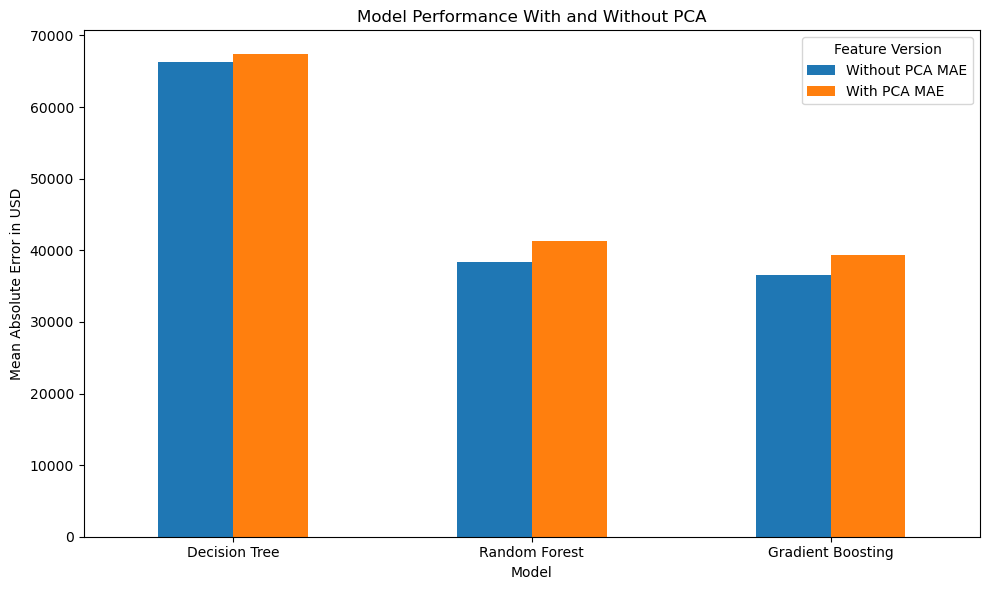

In [43]:
## Visualise whether PCA improved or worsened each algorithm
pca_plot = pca_comparison.set_index("Model")[["Without PCA MAE", "With PCA MAE"]]
pca_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance With and Without PCA")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error in USD")
plt.xticks(rotation=0)
plt.legend(title="Feature Version")
plt.tight_layout()
plt.show()

PCA is rejected because its compressed components produced higher MAE for Decision Tree, Random Forest and Gradient Boosting in the Salary 4.0 experiment. The original encoded features are also easier to explain because they retain readable country, role, education and work-context columns.

In [44]:
## Compare the baseline with the untuned and tuned shortlisted models
final_results = pd.DataFrame(model_results).drop_duplicates("Model", keep="last")
models_to_compare = ["Median Baseline", "Random Forest", "Tuned Random Forest", "Gradient Boosting", "Tuned Gradient Boosting"]
final_comparison = final_results[final_results["Model"].isin(models_to_compare)].copy()

baseline_mae = final_comparison.loc[final_comparison["Model"] == "Median Baseline", "MAE"].iloc[0]
final_comparison["MAE Improvement vs Baseline (%)"] = ((baseline_mae - final_comparison["MAE"]) / baseline_mae * 100).round(2)
final_comparison = final_comparison.sort_values("MAE").reset_index(drop=True)

final_comparison

IndexError: single positional indexer is out-of-bounds

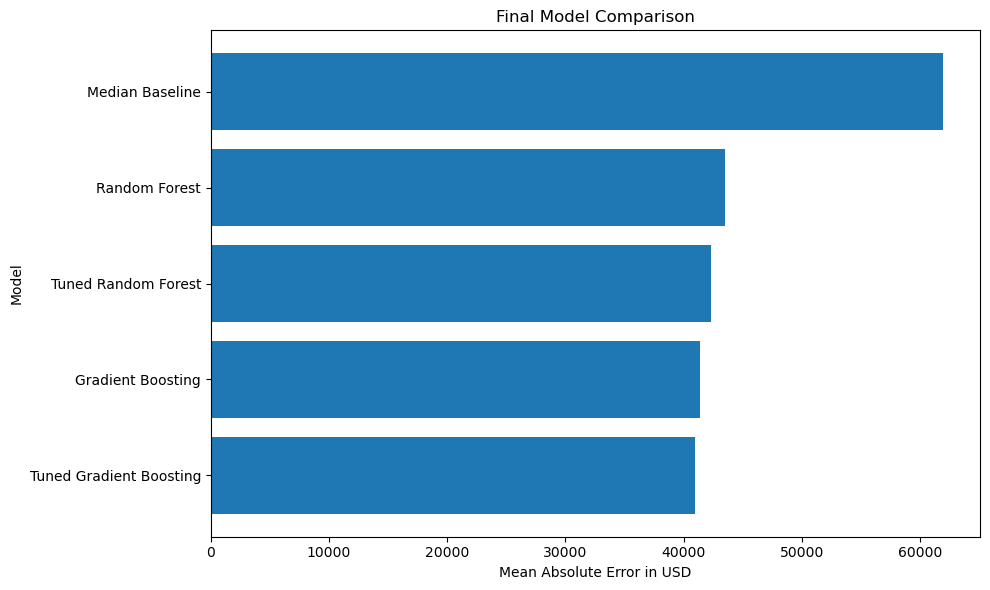

In [ ]:
## Visualise the final MAE ranking so tuning gains are easy to compare
plot_results = final_comparison.sort_values("MAE", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_results["Model"], plot_results["MAE"])
plt.title("Final Model Comparison")
plt.xlabel("Mean Absolute Error in USD")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [ ]:
## Select the strongest non-baseline model using the lowest test MAE
candidate_models = {"Random Forest": rtree, "Tuned Random Forest": rtree_tuned, "Gradient Boosting": gtree, "Tuned Gradient Boosting": gtree_tuned}
candidate_predictions = {"Random Forest": y_pred_rtree, "Tuned Random Forest": y_pred_rtree_tuned, "Gradient Boosting": y_pred_gtree, "Tuned Gradient Boosting": y_pred_gtree_tuned}

best_model_name = final_comparison[final_comparison["Model"] != "Median Baseline"].iloc[0]["Model"]
final_model = candidate_models[best_model_name]
final_prediction = candidate_predictions[best_model_name]

print("Final selected model:", best_model_name)
print("Final model uses: Original encoded features without PCA")

Final selected model: Tuned Gradient Boosting
Final model uses: Original encoded features without PCA


The final model is chosen by the lowest MAE in normal USD, provided that it also improves on the median baseline. Untuned models remain eligible because tuning should only be retained when it produces a genuine improvement; added complexity is not treated as an improvement by itself.

**Student input required after running all cells:** State the selected model, its MAE, its improvement over the baseline and why that error level is acceptable or still limited for the intended user.

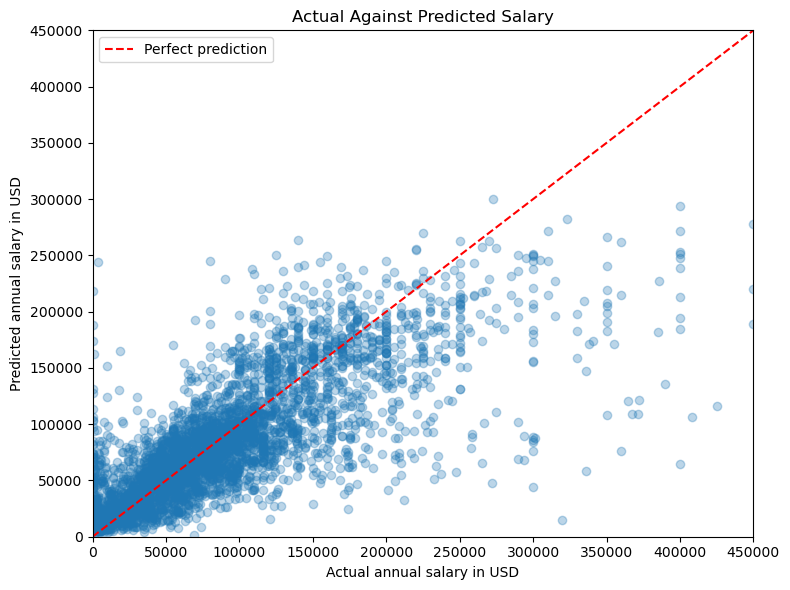

In [ ]:
## Compare actual and predicted salaries while limiting the display to the 99th percentile
salary_plot_limit = y_test.quantile(0.99)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, final_prediction, alpha=0.3)
plt.plot([0, salary_plot_limit], [0, salary_plot_limit], color="red", linestyle="--", label="Perfect prediction")
plt.xlim(0, salary_plot_limit)
plt.ylim(0, salary_plot_limit)
plt.title("Actual Against Predicted Salary")
plt.xlabel("Actual annual salary in USD")
plt.ylabel("Predicted annual salary in USD")
plt.legend()
plt.tight_layout()
plt.show()

Points close to the red diagonal are more accurate predictions, while large vertical distances show substantial errors. The visible spread indicates that the selected survey features provide useful signal but cannot explain every individual salary difference.

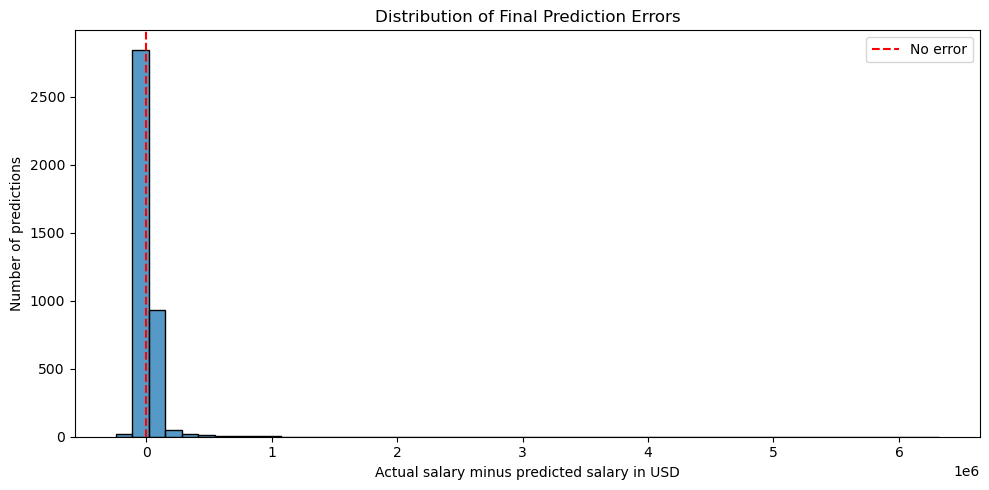

In [ ]:
## Inspect whether final-model errors are centred around zero or strongly skewed
residuals = y_test.to_numpy() - final_prediction

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=50)
plt.axvline(x=0, color="red", linestyle="--", label="No error")
plt.title("Distribution of Final Prediction Errors")
plt.xlabel("Actual salary minus predicted salary in USD")
plt.ylabel("Number of predictions")
plt.legend()
plt.tight_layout()
plt.show()

Residuals near zero indicate accurate estimates. A long tail shows that unusual compensation records remain difficult to predict, which explains why RMSE can stay high even when MAE improves substantially over the baseline.

In [ ]:
## Rank readable inputs because the final non-PCA tree model exposes feature importance
feature_importance = pd.DataFrame({
    "Feature": x_train_encoded.columns,
    "Importance": final_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
23,Country_United States of America,0.319586
1,YearsCode,0.175083
0,WorkExp,0.137972
15,Country_Other,0.073459
11,Country_India,0.054453
21,Country_Ukraine,0.030016
5,Country_Brazil,0.028516
65,RemoteWork_In-person,0.020932
20,Country_Switzerland,0.014767
53,"OrgSize_10,000 or more employees",0.010924


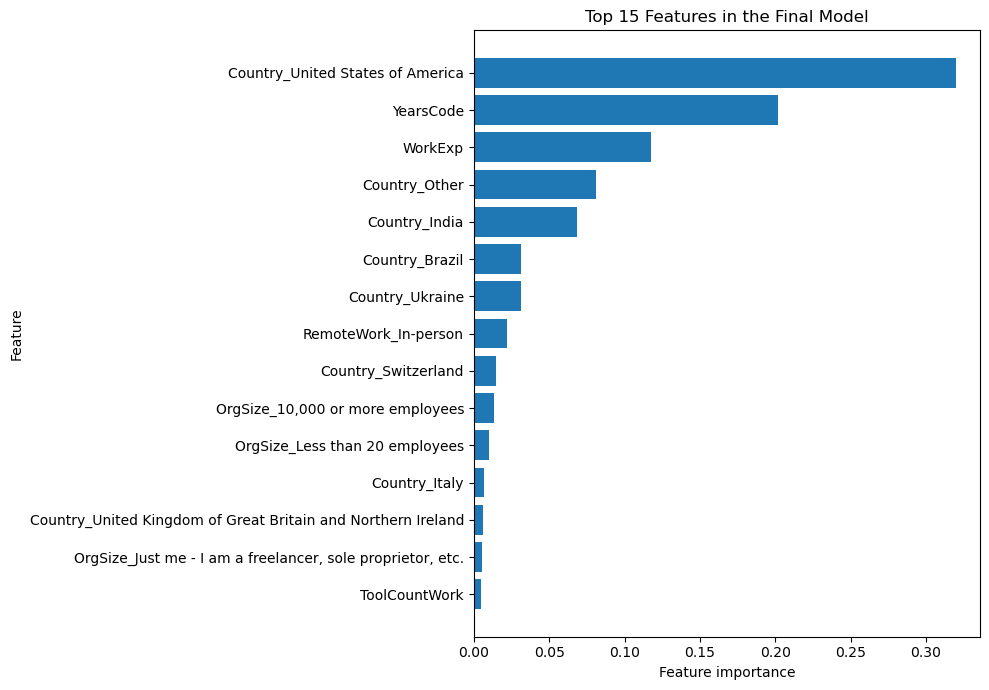

In [ ]:
## Plot the strongest final-model features to support the selection rationale
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 15 Features in the Final Model")
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Feature importance shows which encoded inputs the final tree model used most strongly, but it does not prove that those features cause higher or lower salary. The result should be compared with the EDA patterns for country, role, experience and work arrangement.

In [ ]:
## Compare salary statistics in the training and testing sets

salary_split_summary = pd.DataFrame({
    "Training Set": [
        y_train.min(),
        y_train.max(),
        y_train.mean(),
        y_train.std()
    ],
    "Testing Set": [
        y_test.min(),
        y_test.max(),
        y_test.mean(),
        y_test.std()
    ]
}, index=["Minimum", "Maximum", "Mean", "Standard Deviation"])

salary_split_summary.round(2)

,Training Set,Testing Set
Minimum,2.00,2.00
Maximum,33552715.00,6371285.00
Mean,103237.04,98400.43
Standard Deviation,375840.84,136279.18


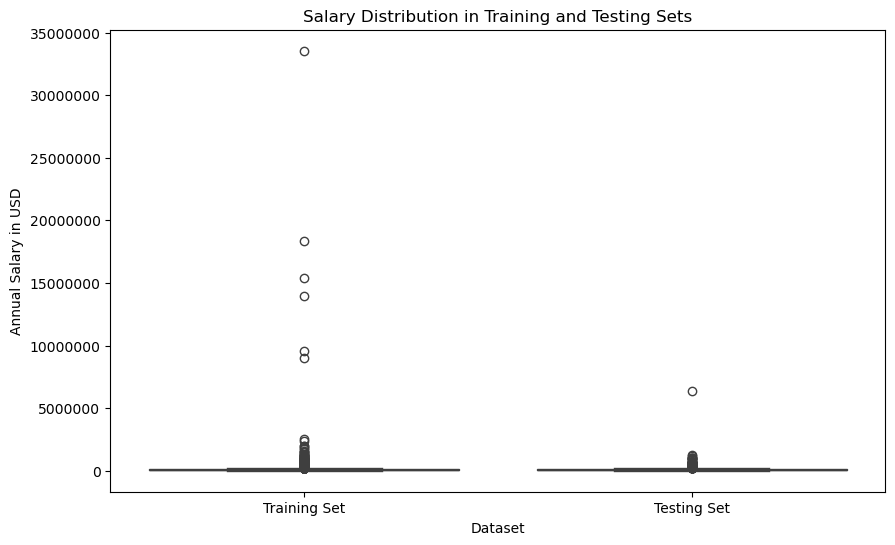

In [ ]:
## Compare the salary distributions in the training and testing sets

salary_split_plot = pd.DataFrame({
    "Salary": pd.concat([
        y_train.reset_index(drop=True),
        y_test.reset_index(drop=True)
    ]),
    "Dataset": (
        ["Training Set"] * len(y_train) +
        ["Testing Set"] * len(y_test)
    )
})

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=salary_split_plot,
    x="Dataset",
    y="Salary"
)

plt.title("Salary Distribution in Training and Testing Sets")
plt.xlabel("Dataset")
plt.ylabel("Annual Salary in USD")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

In [47]:
## Save the final model and preprocessing information for Streamlit

import joblib


model_package = {
    "model": gtree_tuned,
    "model_name": "GradientBoostingRegressor + Hyperparams Tuning",
    "target_transform": "log1p",
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "training_medians": training_medians,
    "category_limits": category_limits,
    "top_categories": top_categories,
    "training_category_levels": training_category_levels,
    "categorical_encoded_columns": x_train_categorical.columns.tolist(),
    "final_encoded_columns": x_train_encoded.columns.tolist()
}

joblib.dump(
    model_package,
    "salary_model_4_1.pkl"
)

print("Saved salary_model_4_1.pkl successfully")

Saved salary_model_4_1.pkl successfully


### Development Log

| Version | Visible iteration evidence | Result or decision |
|---|---|---|
| Salary 3.0 | Used the same 14 main features, no final PCA and `random_state=676767`. | Tuned Gradient Boosting achieved approximately USD 36,320 MAE. |
| Salary 4.0 initial experiment | Added stricter cleaning, tested PCA across DT/RF/GBT, changed the split to `random_state=676767`, and tuned RF and GBT. | Tuned Gradient Boosting achieved approximately USD 41,056 MAE; the result is not directly comparable with Version 3 because the test rows changed. |
| Salary 4.0 correction | Removed the duplicated rare-category grouping cell, removed the undefined `selected_model_name` block, standardised naming and reorganised the notebook into the prescribed template. | Restart the kernel and run all cells to generate the corrected metrics. |

Version 4 remains useful because it records that PCA worsened the three tested tree algorithms and that an untuned Decision Tree fell below the median baseline. It does not replace Version 3 solely because it has a higher version number.

